# Notebook 2 Baseline Prediction

## Import Library

In [1]:
import pandas as pd
import numpy as np
import os
import random

# for visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# for fastai
from fastai.vision.all import *

# for log_loss
from sklearn.metrics import log_loss
import torch.nn.functional as F

# K-Fold Split
from sklearn.model_selection import StratifiedGroupKFold

# Early stop (for fine tune)
from fastai.callback.tracker import EarlyStoppingCallback, SaveModelCallback

# Models
from torchvision.models import resnet101

In [2]:
# Allow full column width display in Pandas
pd.set_option('display.max_colwidth', None)

## Load train data

In [3]:
trn_label = pd.read_csv('/kaggle/input/competition-files/train_labels.csv')
trn_fea = pd.read_csv('/kaggle/input/competition-files/train_features.csv')

## Load test data

In [4]:
# Read the CSV
test_df = pd.read_csv('/kaggle/input/competition-files/test_features.csv')
test_df.head()

,id,filepath,site
0,ZJ016488,test_features/ZJ016488.jpg,S0082
1,ZJ016489,test_features/ZJ016489.jpg,S0040
2,ZJ016490,test_features/ZJ016490.jpg,S0040
3,ZJ016491,test_features/ZJ016491.jpg,S0041
4,ZJ016492,test_features/ZJ016492.jpg,S0040


In [5]:
# Get list of image paths
test_dir = Path('/kaggle/input/competition-files/') 
test_files = [test_dir/f for f in test_df['filepath']]
print("Loaded image count:", len(test_files))     # should be 4464

Loaded image count: 4464


# 1. Check for validation set

In [6]:
# Merge train features and labels on 'id'
df = pd.merge(trn_fea, trn_label, on='id')

# Preview merged dataframe
df.head(5)

,id,filepath,site,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ000000,train_features/ZJ000000.jpg,S0120,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ZJ000001,train_features/ZJ000001.jpg,S0069,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,ZJ000002,train_features/ZJ000002.jpg,S0009,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ZJ000003,train_features/ZJ000003.jpg,S0008,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,ZJ000004,train_features/ZJ000004.jpg,S0036,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [7]:
# Convert one-hot columns into a single label column
classes = ['antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog', 'leopard', 'monkey_prosimian', 'rodent']
df['label'] = df[classes].idxmax(axis=1)

# Check result for id and result
df[['id', 'label']].head(5)

,id,label
0,ZJ000000,bird
1,ZJ000001,monkey_prosimian
2,ZJ000002,bird
3,ZJ000003,monkey_prosimian
4,ZJ000004,leopard


In [8]:
# Add full image path
df['image_path'] = '/kaggle/input/competition-files/' + df['filepath']

# Check path
df[['filepath', 'image_path']].head(5)

,filepath,image_path
0,train_features/ZJ000000.jpg,/kaggle/input/competition-files/train_features/ZJ000000.jpg
1,train_features/ZJ000001.jpg,/kaggle/input/competition-files/train_features/ZJ000001.jpg
2,train_features/ZJ000002.jpg,/kaggle/input/competition-files/train_features/ZJ000002.jpg
3,train_features/ZJ000003.jpg,/kaggle/input/competition-files/train_features/ZJ000003.jpg
4,train_features/ZJ000004.jpg,/kaggle/input/competition-files/train_features/ZJ000004.jpg


In [9]:
# Convert label to digit (0~7)
df['label_code'] = df['label'].astype('category').cat.codes

# Create fold column
df['fold'] = -1

# Set up splitter
skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Assign fold numbers
for fold, (train_idx, val_idx) in enumerate(skf.split(df, df['label_code'], groups=df['site'])):
    df.loc[val_idx, 'fold'] = fold

In [10]:
# Display the site that are split into different fold
for fold in sorted(df['fold'].unique()):
    sites_in_fold = df[df['fold'] == fold]['site'].unique()
    print(f"Fold {fold} sites ({len(sites_in_fold)}): {sites_in_fold}")

Fold 0 sites (28): ['S0019' 'S0014' 'S0105' 'S0068' 'S0042' 'S0184' 'S0074' 'S0157' 'S0095'
 'S0031' 'S0046' 'S0005' 'S0158' 'S0179' 'S0163' 'S0002' 'S0104' 'S0175'
 'S0146' 'S0164' 'S0173' 'S0085' 'S0129' 'S0045' 'S0138' 'S0119' 'S0198'
 'S0143']
Fold 1 sites (30): ['S0036' 'S0060' 'S0059' 'S0080' 'S0075' 'S0038' 'S0170' 'S0070' 'S0021'
 'S0026' 'S0004' 'S0081' 'S0127' 'S0108' 'S0155' 'S0136' 'S0013' 'S0156'
 'S0084' 'S0137' 'S0172' 'S0193' 'S0183' 'S0169' 'S0106' 'S0094' 'S0113'
 'S0182' 'S0178' 'S0006']
Fold 2 sites (30): ['S0009' 'S0061' 'S0188' 'S0097' 'S0077' 'S0022' 'S0089' 'S0025' 'S0024'
 'S0018' 'S0125' 'S0110' 'S0112' 'S0122' 'S0130' 'S0174' 'S0056' 'S0020'
 'S0030' 'S0096' 'S0029' 'S0133' 'S0161' 'S0101' 'S0177' 'S0131' 'S0117'
 'S0098' 'S0190' 'S0007']
Fold 3 sites (29): ['S0120' 'S0008' 'S0047' 'S0076' 'S0049' 'S0063' 'S0027' 'S0035' 'S0051'
 'S0123' 'S0001' 'S0023' 'S0043' 'S0088' 'S0186' 'S0153' 'S0144' 'S0147'
 'S0176' 'S0150' 'S0017' 'S0180' 'S0044' 'S0167' 'S0196' 'S

In [11]:
# Use fold 0 for validation
fold = 0
df_train = df[df['fold'] != fold]
df_valid = df[df['fold'] == fold]

We modified the training data to help the model generalize better:
- Used aug_transforms with:
    - Random horizontal and vertical flip
        - Animals can appear in different orientations in camera trap images.
        - Flipping teaches the model not to depend on a fixed direction (like always expecting an animal to face right), which improves robustness.
    - Rotation up to 15°
        - Some cameras might not be perfectly level, or animals may be captured at odd angles.
        - Adding rotation makes the model less sensitive to small orientation changes and improves spatial awareness.
    - Zoom up to 1.2×
        - Animals may appear closer or farther from the camera.
        - Zoom augmentation mimics this variability and helps the model learn features at different scales. 
    - Lighting changes (brightness/contrast)
        - Lighting conditions can vary drastically in wildlife photography (e.g. day vs night, sun vs shadow).
        - Adjusting brightness/contrast forces the model to focus on shape and texture, not lighting alone.
    - RandomErasing
        - Helps the model learn to recognize animals even when parts of them are missing or obscured.

All these augmentations improve the model's ability to handle unseen variations in the test set, leading to better generalization and often lower log loss even if accuracy doesn’t increase directly.

In [12]:
# Set seed for reproducibility
set_seed(42)

# Create DataBlock with augmentations
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_x=ColReader('image_path'),
    get_y=ColReader('label'),
    splitter=IndexSplitter(df_valid.index),
    item_tfms=RandomResizedCrop(224, min_scale=0.7),  # Replace Resize with random crop
    batch_tfms = [
        *aug_transforms(mult=1.0, do_flip=True, flip_vert=True, max_rotate=15.0, max_zoom=1.2, max_lighting=0.2),
        RandomErasing(p=0.7, max_count=8, sh=0.1)
    ]
)

Removed MixUp and try only with RandomErasing

In [13]:
# Create DataLoaders
dls = dblock.dataloaders(df, bs=64)

In [14]:
learn = vision_learner(dls, resnet101, metrics=[accuracy, error_rate])

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth
100%|██████████| 171M/171M [00:02<00:00, 82.5MB/s]


In [15]:
# Set the custom loss function
learn.loss_func = LabelSmoothingCrossEntropy(eps=0.1)

In [16]:
# Check for validation set
len(learn.dls.valid.items)

2220

As the vallidation set is ready we can go for the next step

# 2. Repeat the baseline training
For better result using unfreeze + lower LR.

SuggestedLRs(valley=0.0012022644514217973)

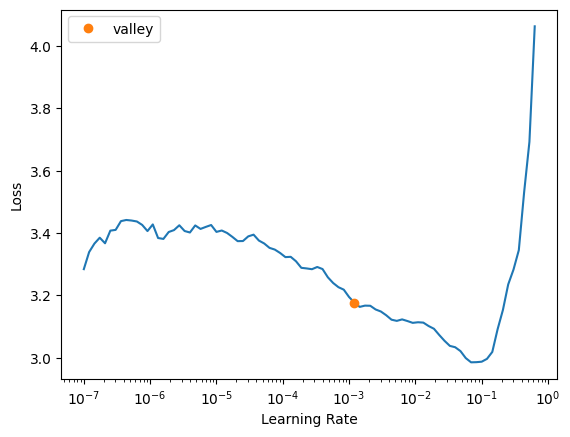

In [17]:
learn.lr_find()
# Result: SuggestedLRs(valley=0.00010964782268274575), SuggestedLRs(valley=6.30957365501672e-05)

In [18]:
# learn.fit_one_cycle(3, 3e-3)     # train head (frozen backbone)
learn.fine_tune(6)

epoch,train_loss,valid_loss,accuracy,error_rate,time
0,2.040630,1.967820,0.369369,0.630631,01:37


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,1.547653,1.700019,0.436036,0.563964,02:06
1,1.301199,1.621194,0.428378,0.571622,02:06
2,1.137193,1.623626,0.463063,0.536937,02:06
3,1.023880,1.531005,0.502252,0.497748,02:06
4,0.960528,1.547915,0.494595,0.505405,02:06
5,0.920339,1.534227,0.504955,0.495045,02:06


In [19]:
# Get validation using TTA
tta_preds, tta_targs = learn.tta(dl=learn.dls.valid)

# 3. Set up the competition metric (Log Loss)

In [20]:
# Get list of class names in the same order as model output
class_names = learn.dls.vocab
class_names

['antelope_duiker', 'bird', 'blank', 'civet_genet', 'hog', 'leopard', 'monkey_prosimian', 'rodent']

In [21]:
# Convert target indices to one-hot encoding
targs_onehot = np.eye(len(class_names))[tta_targs.numpy()]
targs_onehot

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

Use log loss as the validation metric.

In [22]:
# Calculate validation log loss
val_log_loss = log_loss(targs_onehot, tta_preds.numpy())
print(f'Validation Log Loss (TTA): {val_log_loss:.5f}')

Validation Log Loss (TTA): 1.36981


# 4. Prediction Pipeline (with TTA method)

In [23]:
# Create test dataloader from existing DataLoaders
test_dl = learn.dls.test_dl(test_files)

In [24]:
# Get predictions (TTA)
preds, _ = learn.tta(dl=test_dl)

# 5. Save Submission Format

In [25]:
# Create DataFrame with predictions
preds_df = pd.DataFrame(preds.numpy(), columns=learn.dls.vocab)

In [26]:
# Add row_id from test_features.csv
preds_df.insert(0, 'id', test_df['id'])

In [27]:
# Save
preds_df.to_csv('submission.csv', index=False)

In [28]:
# print out the format
df = pd.read_csv('/kaggle/input/competition-files/submission_format.csv')
df.head()

,id,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ016488,0.048233,0.189185,0.044914,0.199588,0.106118,0.132915,0.166410,0.112637
1,ZJ016489,0.097078,0.061400,0.026409,0.241530,0.144344,0.051780,0.287811,0.089648
2,ZJ016490,0.124658,0.089101,0.189225,0.174494,0.180540,0.079995,0.085672,0.076314
3,ZJ016491,0.109966,0.048397,0.055598,0.323600,0.322356,0.063252,0.008160,0.068671
4,ZJ016492,0.165742,0.184610,0.005431,0.136806,0.000389,0.122078,0.151521,0.233423


In [29]:
# print out to check if match the format
df = pd.read_csv('submission.csv')
df.head()

,id,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
0,ZJ016488,0.122381,0.020566,0.359092,0.140875,0.006654,0.223867,0.050754,0.075810
1,ZJ016489,0.500071,0.210039,0.040167,0.034405,0.089354,0.010425,0.077286,0.038252
2,ZJ016490,0.360921,0.067360,0.048619,0.335563,0.083604,0.015977,0.057284,0.030673
3,ZJ016491,0.010298,0.027100,0.028828,0.037824,0.059250,0.783175,0.011956,0.041569
4,ZJ016492,0.184138,0.030902,0.034285,0.036536,0.011407,0.024658,0.429536,0.248538


# Submit to Kaggle & Record Public Score

## Initial result = 1.7160
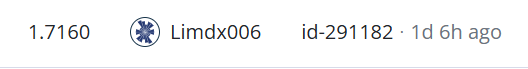

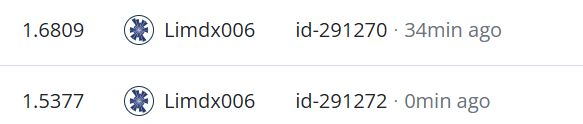
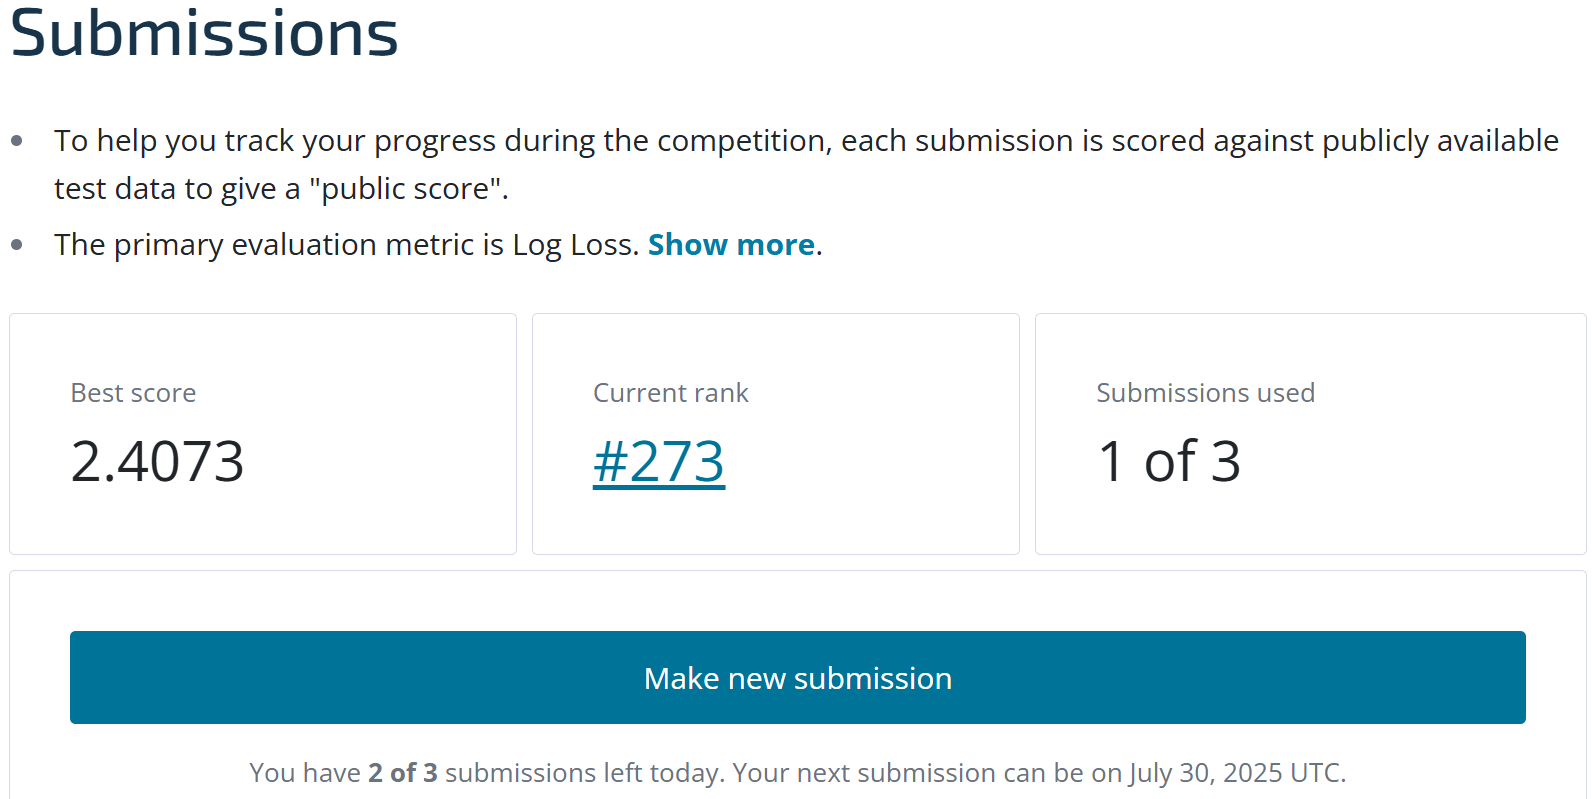
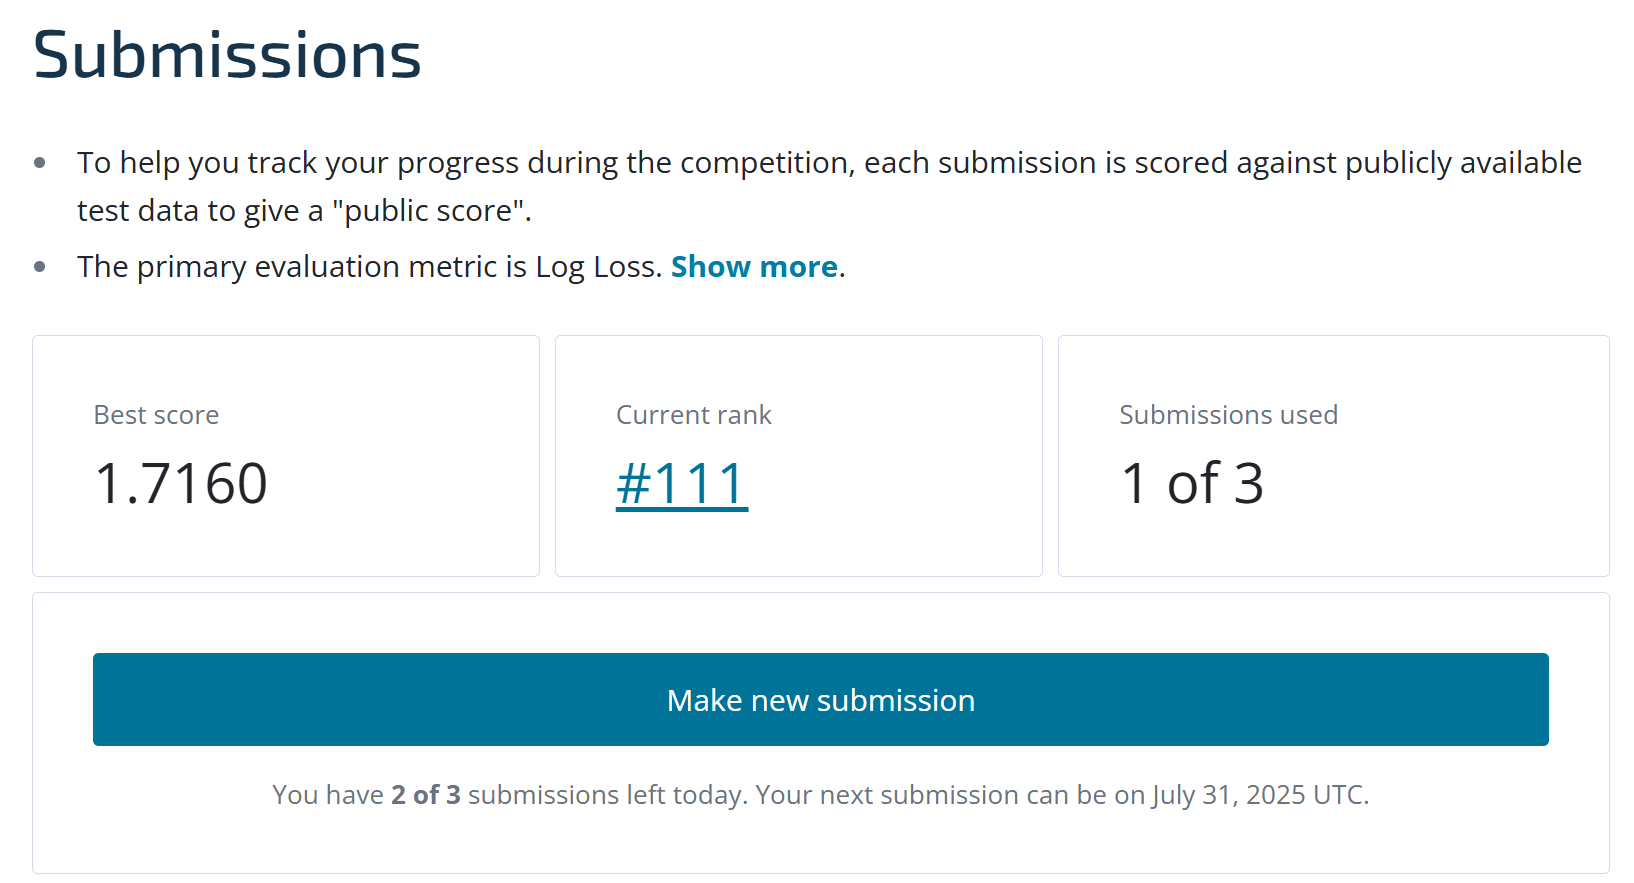

- After added aug score: 1.6809 
- After changing the find_tine and remove mixup: 1.5377

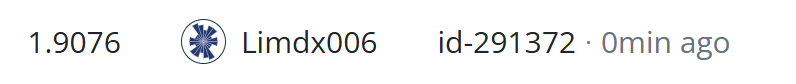

- Result: 1.9076
- 10 epochs seem to be an overfitting, letting the model not performe well in unseen data

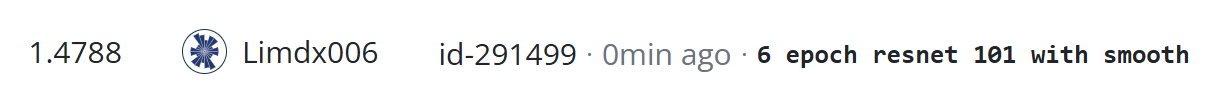

- Using 6 epoch and Label Smoothing Cross Entrop
- Result in great increase of performance to 1.4788
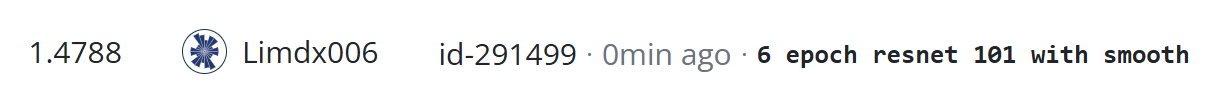

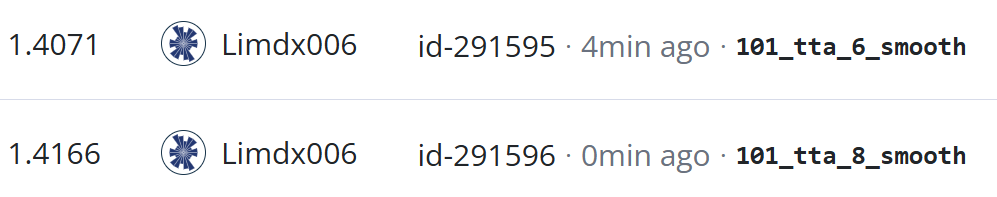


- The result future improve using tta pred with 6 epoch and custom loss
- I also tried 8 epoch that didn't make the performace better so just stick with 6 epoch

# 6. Reflection

Initially, the ResNet101 model achieved a log loss of 1.7160. To improve generalisation and performance, data augmentation techniques were introduced — including random flips, rotation, zoom, MixUp, and lighting adjustments. This slightly reduced the log loss to 1.6809, suggesting minor improvements in the model’s ability to generalise.

Next, the model was retrained using fine_tune without MixUp, which led to a more significant improvement, bringing the log loss down to 1.5377. This suggests that the previous setup may have suffered from over-regularisation or instability introduced by MixUp. Removing MixUp and allowing all layers to be fine-tuned helped the model better capture the underlying patterns, leading to better-calibrated predictions. After some testing, I found that the best training progress was achieved using fine_tune without manually setting the learning rate, allowing FastAI to choose the learning rate automatically.

Further experimentation showed that training for 10 epochs resulted in overfitting, with the log loss increasing to 1.9076 — indicating the model performed worse on unseen data. Reducing the training to 6 epochs and introducing the Label Smoothing Cross Entropy loss function significantly improved the model’s performance, reducing the log loss to 1.4788. This custom loss helped smooth the model’s confidence on predictions and reduced overconfidence, leading to better generalisation.

The result further improved after applying Test Time Augmentation (TTA) during prediction, which averaged predictions over augmented versions of test images, helping reduce variance and boosting robustness. I also tried training for 8 epochs, but performance did not improve further — confirming that 6 epochs was the optimal point for this setup currently.

Overall, these results highlight the importance of careful tuning in training strategies, loss functions, and augmentations — all of which can meaningfully impact deep learning model performance on classification tasks.

# Save prediction 
- This stores the softmax prediction probabilities, which are essential for combining predictions from multiple models during ensembling.

In [30]:
np.save('resnet101_preds.npy', preds.numpy())

In [31]:
learn.export('resnet101_model.pkl')